In [2]:
!pip install meteostat


In [3]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
# Meteostat library
from meteostat import Point, Daily, Hourly

In [12]:
# ================================
# Meteostat: Hourly Weather for Pune
# ================================

from meteostat import Point, Hourly
from datetime import datetime
import pandas as pd

# Time period (shorter range = faster fetch)
start = datetime(2025, 1, 1)
end = datetime(2025,9 , 9)

# Pune coordinates
location = Point(18.5204, 73.8567)

# Fetch hourly weather data
data = Hourly(location, start, end)
df = data.fetch()

# Check available columns
print("Available columns:", df.columns.tolist())

# Select required features (if available)
features = ['temp', 'pres', 'rhum']  # temperature, pressure, humidity
available_features = [col for col in features if col in df.columns]
df = df[available_features]

# Rename for clarity
df.rename(columns={'temp': 'Temperature', 'pres': 'Pressure', 'rhum': 'Humidity'}, inplace=True)

print("\nCleaned DataFrame:")
print(df.head())


Available columns: ['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'coco']

Cleaned DataFrame:
                     Temperature  Pressure  Humidity
time                                                
2025-01-01 00:00:00         16.0    1015.6      96.0
2025-01-01 01:00:00         17.0    1016.0      84.0
2025-01-01 02:00:00         17.1    1016.6      84.0
2025-01-01 03:00:00         17.2    1017.2      94.0
2025-01-01 04:00:00         22.0    1017.8      68.0


In [18]:
model = IsolationForest(
    contamination=0.04,  # 4%anomoly
    random_state=42
)

df['anomaly'] = model.fit_predict(df[['Temperature', 'Pressure', 'Humidity']])

# -1 = anomaly, 1 = normal
df['anomaly_flag'] = df['anomaly'].apply(lambda x: 'Outlier' if x == -1 else 'Normal')


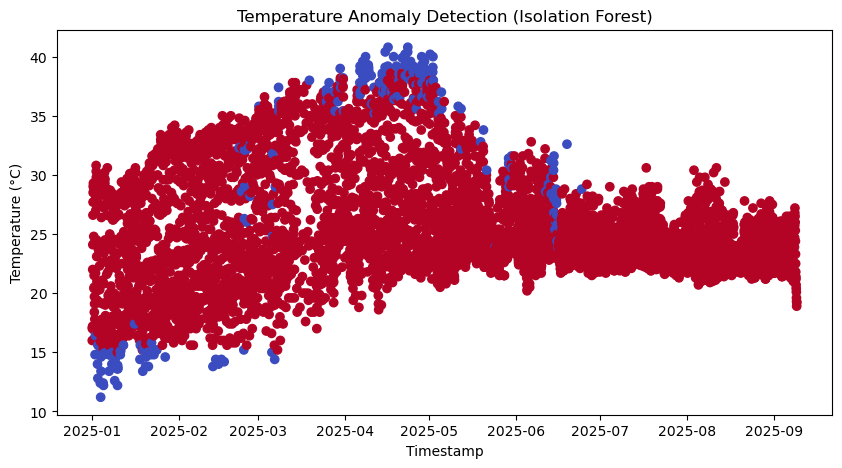


Total anomalies detected: 241
                     Temperature  Pressure  Humidity  anomaly anomaly_flag
time                                                                      
2025-01-02 00:00:00         14.8    1015.0      98.0       -1      Outlier
2025-01-02 03:00:00         16.4    1016.9      98.0       -1      Outlier
2025-01-02 21:00:00         14.0    1015.7      89.0       -1      Outlier
2025-01-03 00:00:00         12.8    1016.8      93.0       -1      Outlier
2025-01-03 02:00:00         15.6    1017.6      82.0       -1      Outlier


In [19]:
# -------------------------------
# Step 3: Visualize anomalies
# -------------------------------
plt.figure(figsize=(10,5))
plt.scatter(df.index, df['Temperature'], 
            c=df['anomaly'], cmap='coolwarm', label='Temperature')
plt.title("Temperature Anomaly Detection (Isolation Forest)")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")

plt.show()

# -------------------------------
# Step 4: Print anomaly summary
# -------------------------------
outliers = df[df['anomaly'] == -1]
print(f"\nTotal anomalies detected: {len(outliers)}")
print(outliers.head())


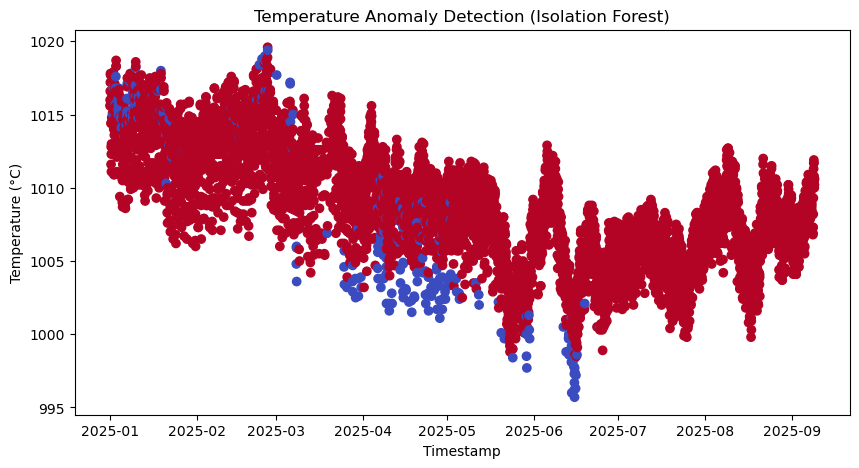


Total anomalies detected: 241
                     Temperature  Pressure  Humidity  anomaly anomaly_flag
time                                                                      
2025-01-02 00:00:00         14.8    1015.0      98.0       -1      Outlier
2025-01-02 03:00:00         16.4    1016.9      98.0       -1      Outlier
2025-01-02 21:00:00         14.0    1015.7      89.0       -1      Outlier
2025-01-03 00:00:00         12.8    1016.8      93.0       -1      Outlier
2025-01-03 02:00:00         15.6    1017.6      82.0       -1      Outlier


In [20]:
# -------------------------------
# Step 3: Visualize anomalies
# -------------------------------
plt.figure(figsize=(10,5))
plt.scatter(df.index, df['Pressure'], 
            c=df['anomaly'], cmap='coolwarm', label='Temperature')
plt.title("Temperature Anomaly Detection (Isolation Forest)")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")

plt.show()

# -------------------------------
# Step 4: Print anomaly summary
# -------------------------------
outliers = df[df['anomaly'] == -1]
print(f"\nTotal anomalies detected: {len(outliers)}")
print(outliers.head())

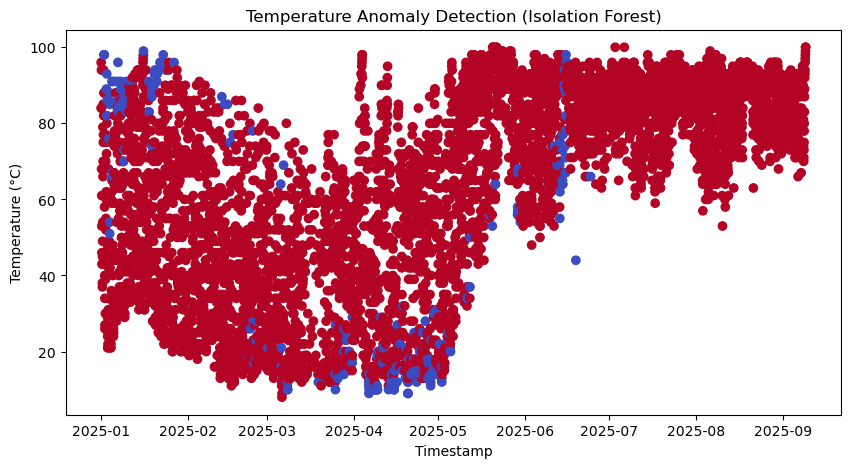


Total anomalies detected: 241
                     Temperature  Pressure  Humidity  anomaly anomaly_flag
time                                                                      
2025-01-02 00:00:00         14.8    1015.0      98.0       -1      Outlier
2025-01-02 03:00:00         16.4    1016.9      98.0       -1      Outlier
2025-01-02 21:00:00         14.0    1015.7      89.0       -1      Outlier
2025-01-03 00:00:00         12.8    1016.8      93.0       -1      Outlier
2025-01-03 02:00:00         15.6    1017.6      82.0       -1      Outlier


In [21]:
# -------------------------------
# Step 3: Visualize anomalies
# -------------------------------
plt.figure(figsize=(10,5))
plt.scatter(df.index, df['Humidity'], 
            c=df['anomaly'], cmap='coolwarm', label='Temperature')
plt.title("Temperature Anomaly Detection (Isolation Forest)")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")

plt.show()

# -------------------------------
# Step 4: Print anomaly summary
# -------------------------------
outliers = df[df['anomaly'] == -1]
print(f"\nTotal anomalies detected: {len(outliers)}")
print(outliers.head())